# Seasonal Burn-in Diagnostics (x3_lambda50)

Run: `stagel_3month_burnin_seq_8586x3_lamba_50`

This notebook checks whether repeated-year runs have burned out initial SOC effects.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

RUN_NAME = "stagel_3month_burnin_seq_8586x3_lamba_50"
OUTPUT_ROOT = Path("acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019")
if not OUTPUT_ROOT.exists():
    OUTPUT_ROOT = Path.cwd().parent / "outputs" / "historical_1980_2019"

RUN_DIR = OUTPUT_ROOT / RUN_NAME
MANIFEST = RUN_DIR / "_sequence_manifest.csv"

INPUT_DIR = Path("acorn-julia/runs/low_RE_mod_elec_iter0/inputs")
if not INPUT_DIR.exists():
    INPUT_DIR = Path.cwd().parent / "inputs"
SEASONAL_INPUT = INPUT_DIR / "seasonal_zoneA_test_stage1_3month_pcap2160.csv"

# Set to repeated block length (for 85/86 repeated, this is 2)
BLOCK_LEN = 2

# Convergence thresholds (percent)
TH_START_END_SOC = 1.0
TH_MEAN_SOC = 2.0
TH_THROUGHPUT = 5.0
TH_RELIABILITY = 3.0

print("RUN_DIR:", RUN_DIR)
print("MANIFEST exists:", MANIFEST.exists())
print("SEASONAL_INPUT exists:", SEASONAL_INPUT.exists())


RUN_DIR: /home/fs01/jl2966/acorn-julia2/acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019/stagel_3month_burnin_seq_8586x3_lamba_50
MANIFEST exists: True
SEASONAL_INPUT exists: True


In [2]:
def _strip_tz(idx):
    if hasattr(idx, "tz") and idx.tz is not None:
        return idx.tz_convert(None)
    return idx


def load_storage_state_series(path: Path) -> pd.Series:
    if not path.exists():
        return pd.Series(dtype=float)
    df = pd.read_csv(path)
    if df.empty:
        return pd.Series(dtype=float)

    ts_cols = [c for c in df.columns if c not in ("bus_id", "zone", "end")]
    vals = df[ts_cols].apply(pd.to_numeric, errors="coerce").sum(axis=0)
    vals.index = pd.to_datetime(vals.index, errors="coerce")
    vals = vals[vals.index.notna()]
    vals.index = _strip_tz(vals.index)
    return vals.sort_index()


def load_storage_start_end(path: Path):
    if not path.exists():
        return np.nan, np.nan
    df = pd.read_csv(path)
    if df.empty:
        return np.nan, np.nan
    ts_cols = [c for c in df.columns if c not in ("bus_id", "zone", "end")]
    if len(ts_cols) == 0:
        return np.nan, np.nan
    start = pd.to_numeric(df[ts_cols[0]], errors="coerce").sum()
    end = pd.to_numeric(df["end"], errors="coerce").sum() if "end" in df.columns else np.nan
    return float(start), float(end)


def load_total_time_metric(path: Path) -> float:
    if not path.exists():
        return np.nan
    df = pd.read_csv(path)
    if df.empty:
        return np.nan
    cols = [c for c in df.columns if c not in ("bus_id", "zone", "asset_type")]
    vals = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    return float(vals.to_numpy().sum())


def pct_diff(curr, prev):
    if pd.isna(curr) or pd.isna(prev):
        return np.nan
    denom = abs(prev) if abs(prev) > 1e-9 else np.nan
    if pd.isna(denom):
        return np.nan
    return 100.0 * abs(curr - prev) / denom


manifest = pd.read_csv(MANIFEST)
manifest["seq_idx"] = manifest["seq_idx"].astype(int)
manifest = manifest.sort_values("seq_idx").reset_index(drop=True)
manifest["within_block"] = ((manifest["seq_idx"] - 1) % BLOCK_LEN) + 1
manifest["cycle"] = ((manifest["seq_idx"] - 1) // BLOCK_LEN) + 1

E_total = np.nan
if SEASONAL_INPUT.exists():
    sdf = pd.read_csv(SEASONAL_INPUT)
    if "storage_capacity_mwh" in sdf.columns:
        E_total = float(pd.to_numeric(sdf["storage_capacity_mwh"], errors="coerce").fillna(0.0).sum())

print("Sequence steps:")
display(manifest)
print("Total seasonal energy capacity E_total (MWh):", E_total)


Sequence steps:


,seq_idx,sim_year,token,prev_token,within_block,cycle
0,1,1985,seq001_y1985,NaN,1,1
1,2,1986,seq002_y1986,seq001_y1985,2,1
2,3,1985,seq003_y1985,seq002_y1986,1,2
3,4,1986,seq004_y1986,seq003_y1985,2,2
4,5,1985,seq005_y1985,seq004_y1986,1,3
5,6,1986,seq006_y1986,seq005_y1985,2,3


Total seasonal energy capacity E_total (MWh): 12959770.970515545


In [3]:
rows = []
soc_series = {}

for _, r in manifest.iterrows():
    token = r["token"]
    y = int(r["sim_year"])

    p_soc = RUN_DIR / f"storage_state_seasonal_{token}.csv"
    p_ch = RUN_DIR / f"charge_seasonal_{token}.csv"
    p_dis = RUN_DIR / f"discharge_seasonal_{token}.csv"
    p_ls = RUN_DIR / f"load_shedding_{token}.csv"
    p_w = RUN_DIR / f"wind_curtailment_{token}.csv"
    p_s = RUN_DIR / f"solar_curtailment_{token}.csv"

    start_soc, end_soc = load_storage_start_end(p_soc)
    soc_ts = load_storage_state_series(p_soc)
    soc_series[token] = soc_ts

    rows.append({
        "seq_idx": int(r["seq_idx"]),
        "cycle": int(r["cycle"]),
        "within_block": int(r["within_block"]),
        "sim_year": y,
        "token": token,
        "soc_start_MWh": start_soc,
        "soc_end_MWh": end_soc,
        "soc_delta_MWh": end_soc - start_soc if pd.notna(start_soc) and pd.notna(end_soc) else np.nan,
        "soc_mean_MWh": float(soc_ts.mean()) if len(soc_ts) else np.nan,
        "soc_min_MWh": float(soc_ts.min()) if len(soc_ts) else np.nan,
        "soc_max_MWh": float(soc_ts.max()) if len(soc_ts) else np.nan,
        "seasonal_charge_MWh": load_total_time_metric(p_ch),
        "seasonal_discharge_MWh": load_total_time_metric(p_dis),
        "load_shed_MWh": load_total_time_metric(p_ls),
        "wind_curt_MWh": load_total_time_metric(p_w),
        "solar_curt_MWh": load_total_time_metric(p_s),
    })

step_df = pd.DataFrame(rows).sort_values("seq_idx").reset_index(drop=True)
if pd.notna(E_total) and E_total > 0:
    step_df["soc_start_pct_E"] = 100.0 * step_df["soc_start_MWh"] / E_total
    step_df["soc_end_pct_E"] = 100.0 * step_df["soc_end_MWh"] / E_total
    step_df["soc_delta_pct_E"] = 100.0 * step_df["soc_delta_MWh"] / E_total

pd.set_option("display.max_columns", 50)
display(step_df.round(3))


,seq_idx,cycle,within_block,sim_year,token,soc_start_MWh,soc_end_MWh,soc_delta_MWh,soc_mean_MWh,soc_min_MWh,soc_max_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh,soc_start_pct_E,soc_end_pct_E,soc_delta_pct_E
0,1,1,1,1985,seq001_y1985,3887931.291,3887931.291,0.0,3887931.291,3887931.291,3887931.291,0.0,0.0,818062.823,7113100.424,1.067756e+07,30.0,30.0,0.0
1,2,1,2,1986,seq002_y1986,3887931.291,3887931.291,0.0,3887931.291,3887931.291,3887931.291,0.0,0.0,439652.508,6845514.172,1.096210e+07,30.0,30.0,0.0
2,3,2,1,1985,seq003_y1985,3887931.291,3887931.291,0.0,3887931.291,3887931.291,3887931.291,0.0,0.0,818062.823,7094505.611,1.069461e+07,30.0,30.0,0.0
3,4,2,2,1986,seq004_y1986,3887931.291,3887931.291,0.0,3887931.291,3887931.291,3887931.291,0.0,0.0,439652.508,6845514.172,1.096210e+07,30.0,30.0,0.0
4,5,3,1,1985,seq005_y1985,3887931.291,3887931.291,0.0,3887931.291,3887931.291,3887931.291,0.0,0.0,818062.823,7094505.611,1.069461e+07,30.0,30.0,0.0
5,6,3,2,1986,seq006_y1986,3887931.291,3887931.291,0.0,3887931.291,3887931.291,3887931.291,0.0,0.0,439652.508,6845514.172,1.096210e+07,30.0,30.0,0.0


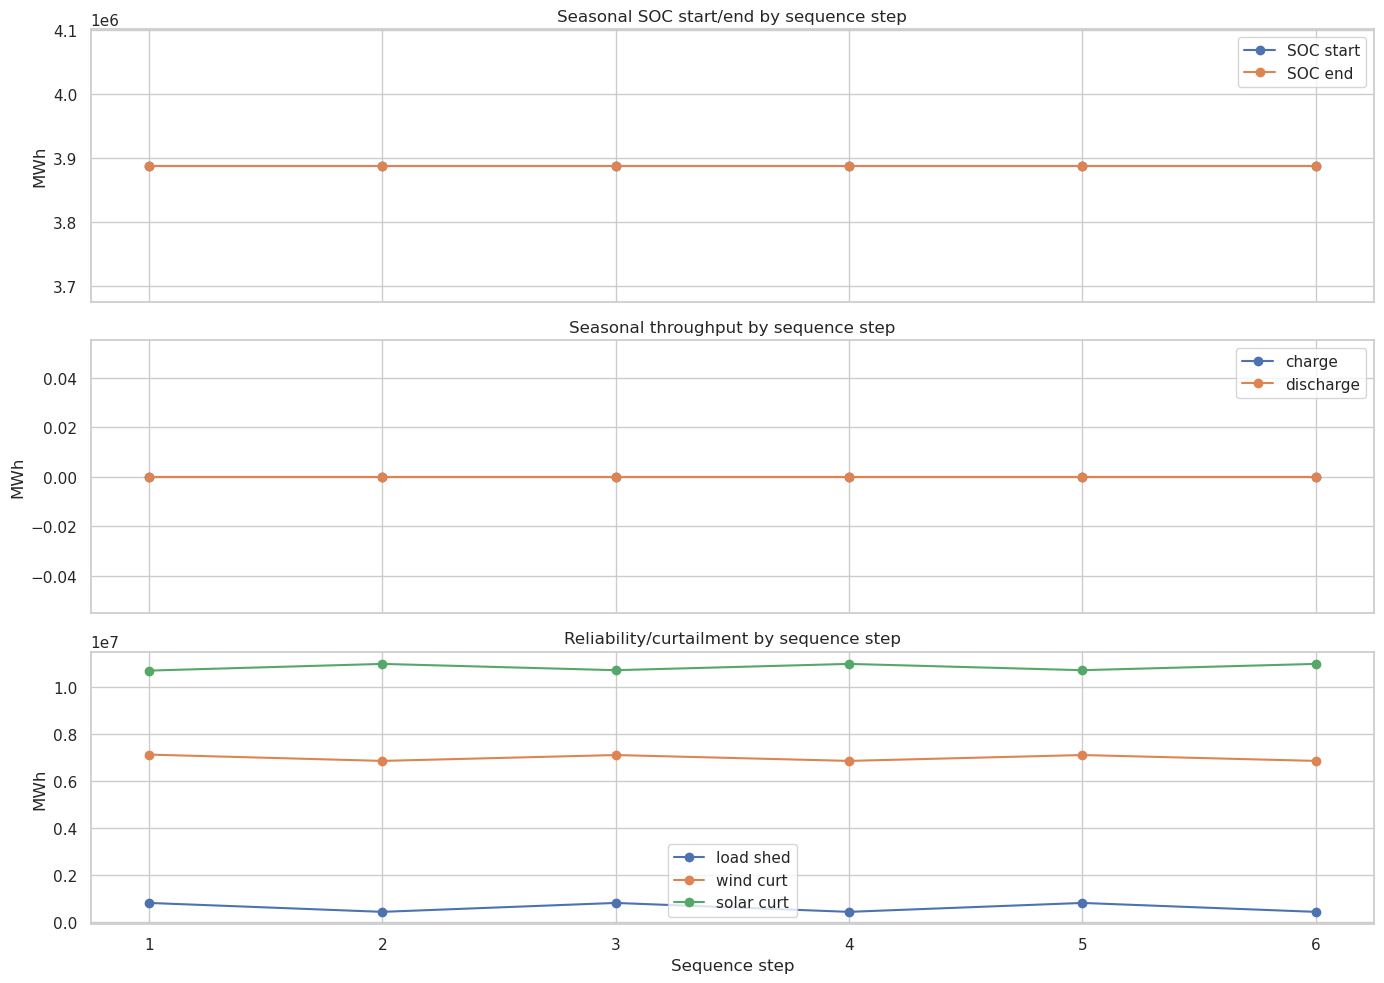

In [4]:
# Quick visual checks
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(step_df["seq_idx"], step_df["soc_start_MWh"], marker="o", label="SOC start")
axes[0].plot(step_df["seq_idx"], step_df["soc_end_MWh"], marker="o", label="SOC end")
axes[0].set_ylabel("MWh")
axes[0].set_title("Seasonal SOC start/end by sequence step")
axes[0].legend()

axes[1].plot(step_df["seq_idx"], step_df["seasonal_charge_MWh"], marker="o", label="charge")
axes[1].plot(step_df["seq_idx"], step_df["seasonal_discharge_MWh"], marker="o", label="discharge")
axes[1].set_ylabel("MWh")
axes[1].set_title("Seasonal throughput by sequence step")
axes[1].legend()

axes[2].plot(step_df["seq_idx"], step_df["load_shed_MWh"], marker="o", label="load shed")
axes[2].plot(step_df["seq_idx"], step_df["wind_curt_MWh"], marker="o", label="wind curt")
axes[2].plot(step_df["seq_idx"], step_df["solar_curt_MWh"], marker="o", label="solar curt")
axes[2].set_ylabel("MWh")
axes[2].set_xlabel("Sequence step")
axes[2].set_title("Reliability/curtailment by sequence step")
axes[2].legend()

plt.tight_layout()
plt.show()


In [5]:
# Convergence check: compare each cycle step to previous cycle's same within-block position
conv_rows = []
for _, curr in step_df.iterrows():
    prev = step_df[(step_df["cycle"] == curr["cycle"] - 1) & (step_df["within_block"] == curr["within_block"])]
    if prev.empty:
        continue
    prev = prev.iloc[0]

    row = {
        "seq_idx": int(curr["seq_idx"]),
        "cycle": int(curr["cycle"]),
        "within_block": int(curr["within_block"]),
        "sim_year": int(curr["sim_year"]),
        "token": curr["token"],
        "d_soc_start_pct": pct_diff(curr["soc_start_MWh"], prev["soc_start_MWh"]),
        "d_soc_end_pct": pct_diff(curr["soc_end_MWh"], prev["soc_end_MWh"]),
        "d_soc_mean_pct": pct_diff(curr["soc_mean_MWh"], prev["soc_mean_MWh"]),
        "d_charge_pct": pct_diff(curr["seasonal_charge_MWh"], prev["seasonal_charge_MWh"]),
        "d_discharge_pct": pct_diff(curr["seasonal_discharge_MWh"], prev["seasonal_discharge_MWh"]),
        "d_load_shed_pct": pct_diff(curr["load_shed_MWh"], prev["load_shed_MWh"]),
        "d_wind_curt_pct": pct_diff(curr["wind_curt_MWh"], prev["wind_curt_MWh"]),
        "d_solar_curt_pct": pct_diff(curr["solar_curt_MWh"], prev["solar_curt_MWh"]),
    }
    row["soc_ok"] = (row["d_soc_start_pct"] <= TH_START_END_SOC) and (row["d_soc_end_pct"] <= TH_START_END_SOC) and (row["d_soc_mean_pct"] <= TH_MEAN_SOC)
    row["throughput_ok"] = (row["d_charge_pct"] <= TH_THROUGHPUT) and (row["d_discharge_pct"] <= TH_THROUGHPUT)
    row["reliability_ok"] = (row["d_load_shed_pct"] <= TH_RELIABILITY) and (row["d_wind_curt_pct"] <= TH_RELIABILITY) and (row["d_solar_curt_pct"] <= TH_RELIABILITY)
    row["all_ok"] = row["soc_ok"] and row["throughput_ok"] and row["reliability_ok"]

    conv_rows.append(row)

conv_df = pd.DataFrame(conv_rows)
display(conv_df.round(3))

if not conv_df.empty:
    last_block = conv_df[conv_df["cycle"] == conv_df["cycle"].max()]
    print("\nConvergence verdict for last cycle:")
    print("All rows meet thresholds:", bool(last_block["all_ok"].all()))
    display(last_block[["seq_idx","token","all_ok","soc_ok","throughput_ok","reliability_ok"]])


,seq_idx,cycle,within_block,sim_year,token,d_soc_start_pct,d_soc_end_pct,d_soc_mean_pct,d_charge_pct,d_discharge_pct,d_load_shed_pct,d_wind_curt_pct,d_solar_curt_pct,soc_ok,throughput_ok,reliability_ok,all_ok
0,3,2,1,1985,seq003_y1985,0.0,0.0,0.0,NaN,NaN,0.0,0.261,0.16,True,False,True,False
1,4,2,2,1986,seq004_y1986,0.0,0.0,0.0,NaN,NaN,0.0,0.000,0.00,True,False,True,False
2,5,3,1,1985,seq005_y1985,0.0,0.0,0.0,NaN,NaN,0.0,0.000,0.00,True,False,True,False
3,6,3,2,1986,seq006_y1986,0.0,0.0,0.0,NaN,NaN,0.0,0.000,0.00,True,False,True,False



Convergence verdict for last cycle:
All rows meet thresholds: False


,seq_idx,token,all_ok,soc_ok,throughput_ok,reliability_ok
2,5,seq005_y1985,False,True,False,True
3,6,seq006_y1986,False,True,False,True


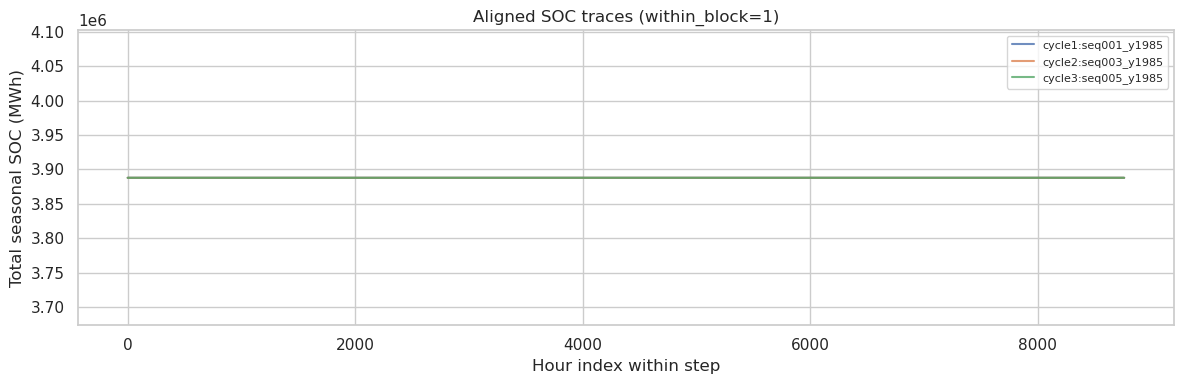

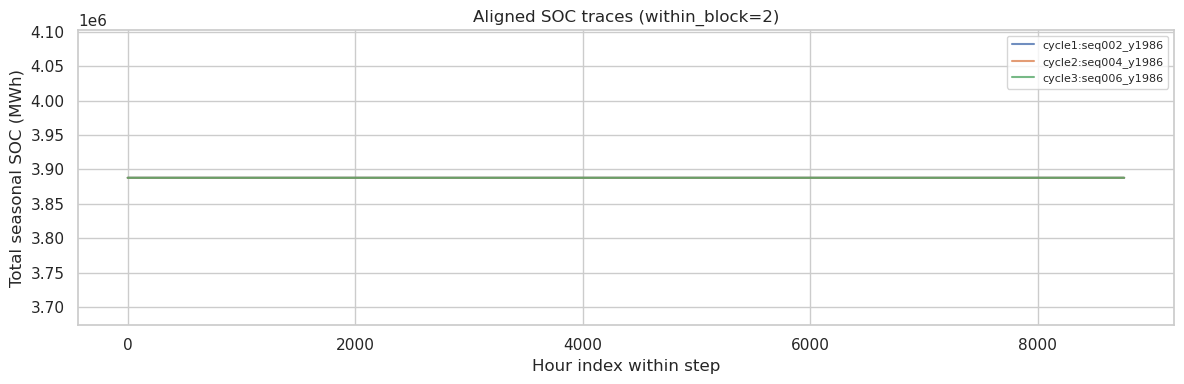

In [6]:
# Aligned SOC traces by within-block position (visual burn-in check)
for pos in sorted(step_df["within_block"].unique()):
    subset = step_df[step_df["within_block"] == pos].sort_values("cycle")
    fig, ax = plt.subplots(figsize=(12,4))
    for _, r in subset.iterrows():
        tok = r["token"]
        s = soc_series.get(tok, pd.Series(dtype=float))
        if s.empty:
            continue
        # Align by step-relative hour index for overlay
        aligned = pd.Series(s.values, index=np.arange(len(s)))
        ax.plot(aligned.index, aligned.values, alpha=0.8, label=f"cycle{int(r['cycle'])}:{tok}")
    ax.set_title(f"Aligned SOC traces (within_block={pos})")
    ax.set_xlabel("Hour index within step")
    ax.set_ylabel("Total seasonal SOC (MWh)")
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


SOC averages/ranges by repeated slot (burn-in check):


,within_block,n_steps,soc_start_mean_MWh,soc_end_mean_MWh,soc_start_min_MWh,soc_start_max_MWh,soc_end_min_MWh,soc_end_max_MWh,soc_start_range_MWh,soc_end_range_MWh,soc_start_mean_pct_E,soc_end_mean_pct_E,soc_start_range_pct_E,soc_end_range_pct_E
0,1,3,3887931.291,3887931.291,3887931.291,3887931.291,3887931.291,3887931.291,0.0,0.0,30.0,30.0,0.0,0.0
1,2,3,3887931.291,3887931.291,3887931.291,3887931.291,3887931.291,3887931.291,0.0,0.0,30.0,30.0,0.0,0.0


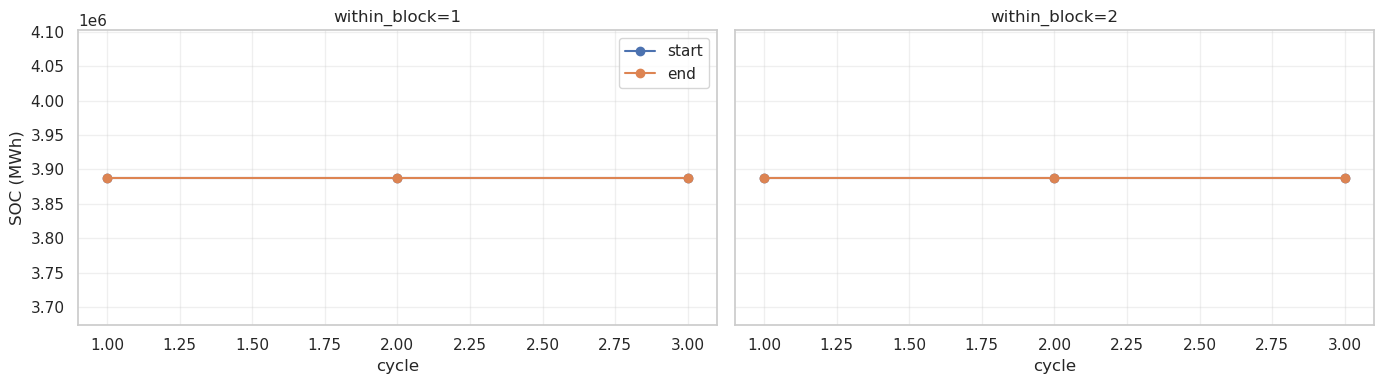

In [7]:
# Professor-style SOC burn-in summary by repeated slot
# within_block=1 -> first year in sequence pattern, within_block=2 -> second year
slot_stats = step_df.groupby("within_block").agg(
    n_steps=("seq_idx", "count"),
    soc_start_mean_MWh=("soc_start_MWh", "mean"),
    soc_end_mean_MWh=("soc_end_MWh", "mean"),
    soc_start_min_MWh=("soc_start_MWh", "min"),
    soc_start_max_MWh=("soc_start_MWh", "max"),
    soc_end_min_MWh=("soc_end_MWh", "min"),
    soc_end_max_MWh=("soc_end_MWh", "max"),
).reset_index()
slot_stats["soc_start_range_MWh"] = slot_stats["soc_start_max_MWh"] - slot_stats["soc_start_min_MWh"]
slot_stats["soc_end_range_MWh"] = slot_stats["soc_end_max_MWh"] - slot_stats["soc_end_min_MWh"]

if "E_total" in globals() and pd.notna(E_total) and E_total > 0:
    slot_stats["soc_start_mean_pct_E"] = 100.0 * slot_stats["soc_start_mean_MWh"] / E_total
    slot_stats["soc_end_mean_pct_E"] = 100.0 * slot_stats["soc_end_mean_MWh"] / E_total
    slot_stats["soc_start_range_pct_E"] = 100.0 * slot_stats["soc_start_range_MWh"] / E_total
    slot_stats["soc_end_range_pct_E"] = 100.0 * slot_stats["soc_end_range_MWh"] / E_total

print("SOC averages/ranges by repeated slot (burn-in check):")
display(slot_stats.round(3))

# Optional: show trend by cycle for each slot
fig, axes = plt.subplots(1, 2, figsize=(14,4), sharey=True)
for pos, ax in zip(sorted(step_df["within_block"].unique()), axes):
    s = step_df[step_df["within_block"] == pos].sort_values("cycle")
    ax.plot(s["cycle"], s["soc_start_MWh"], marker="o", label="start")
    ax.plot(s["cycle"], s["soc_end_MWh"], marker="o", label="end")
    ax.set_title(f"within_block={pos}")
    ax.set_xlabel("cycle")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("SOC (MWh)")
axes[0].legend()
plt.tight_layout()
plt.show()
